#### Monireh Eshghinezhad
#### MAI1202-Assignment #1 - Deep Neural Networks vs Traditional ML
#### Task: Regression — predict house price

### Data Preparation

In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import time
import warnings
warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set seeds for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Use GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Load the dataset
df = pd.read_csv('data/kc_house_data.csv')

Using device: cpu


In [74]:
# Exploratory checks
print(f'Dataset shape: {df.shape}')
# Check for missing values
print('Dtypes & non-null counts:')
print(df.info())

print('\nFirst 5 rows:')
print(df.head())

print('\nBasic statistics:')
df.describe()

Dataset shape: (21613, 21)
Dtypes & non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 1

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


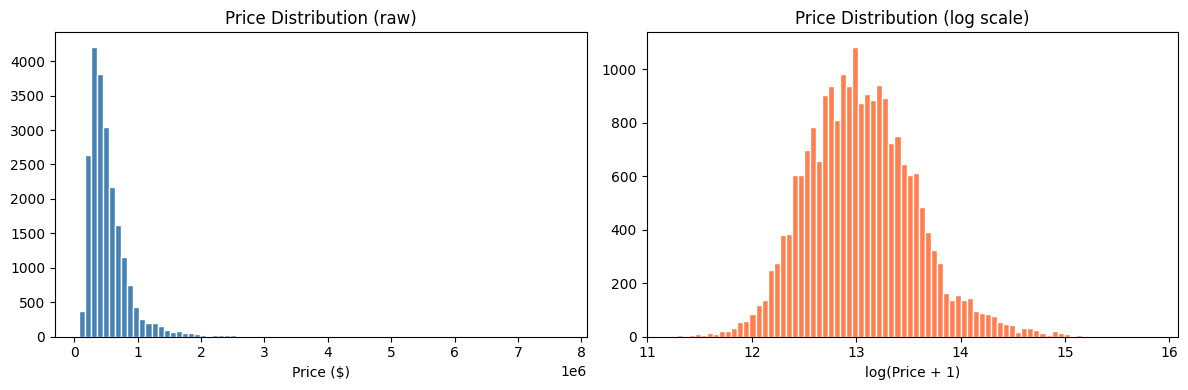

In [75]:
# Visualise the target variable (price)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['price'], bins=80, color='steelblue', edgecolor='white')
axes[0].set_title('Price Distribution (raw)')
axes[0].set_xlabel('Price ($)')

# Prices are heavily right-skewed (a few very expensive mansions).  A log
# transform makes the distribution more bell-shaped and helps models learn.
axes[1].hist(np.log1p(df['price']), bins=80, color='coral', edgecolor='white')
axes[1].set_title('Price Distribution (log scale)')
axes[1].set_xlabel('log(Price + 1)')

plt.tight_layout()
plt.show()

### Feature engineering

Features after engineering: (21613, 21)


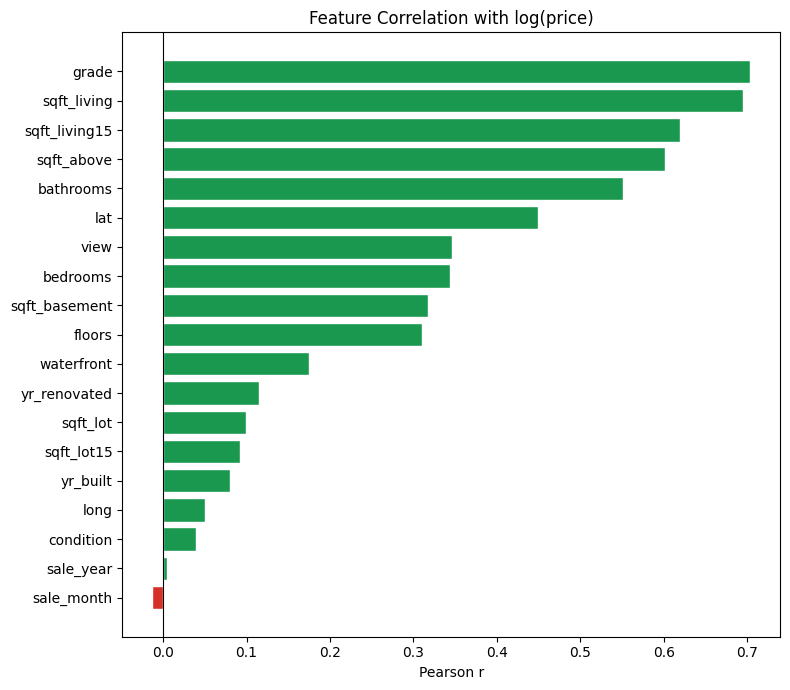

In [ ]:
# Parse the date column and extract year and month of sale
df['date'] = pd.to_datetime(df['date'], format='%Y%m%dT%H%M%S')
df['sale_year']  = df['date'].dt.year
df['sale_month'] = df['date'].dt.month

# Drop columns that are not useful as raw features
# zip codes look like numbers but they are really labels. Treating them as a number would mislead the model
drop_cols = ['id', 'date', 'zipcode']
df.drop(columns=drop_cols, inplace=True)

# Log-transform the target — models will predict log(price), then we exponentiate
# Taking the log makes the distribution more symmetric I will convert predictions back to dollars at evaluation time.
df['log_price'] = np.log1p(df['price'])

print('Features after engineering:', df.shape)

# Feature Correlation with log(price)
corr = df.drop(columns=["price", "log_price"]).corrwith(df["log_price"]).sort_values()

fig, ax = plt.subplots(figsize=(8, 7))
colors = ["#d73027" if v < 0 else "#1a9850" for v in corr.values]
ax.barh(corr.index, corr.values, color=colors, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Pearson r")
ax.set_title("Feature Correlation with log(price)")
plt.tight_layout()
plt.show()

In [77]:
# Features and target value
X = df.drop(columns=['price', 'log_price']).values.astype(np.float32)
y = df['log_price'].values.astype(np.float32)
y_raw = df['price'].values.astype(np.float32)   # kept for final metric display

feature_names = df.drop(columns=['price', 'log_price']).columns.tolist()
print(f'Features ({len(feature_names)}): {feature_names}')

# Train / Val / Test split :  70 % training, 15 % validation, 15 % test.
X_trainval, X_test, y_trainval, y_test, yraw_trainval, yraw_test = train_test_split(
    X, y, y_raw, test_size=0.15, random_state=SEED)

X_train, X_val, y_train, y_val, yraw_train, yraw_val = train_test_split(
    X_trainval, y_trainval, yraw_trainval,
    test_size=0.15/0.85, random_state=SEED)

print(f'Train: {X_train.shape[0]}  Val: {X_val.shape[0]}  Test: {X_test.shape[0]}')

Features (19): ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'sale_year', 'sale_month']
Train: 15129  Val: 3242  Test: 3242


In [78]:
# Feature scaling
scaler = StandardScaler() # subtract mean, divide by std.
X_train_s = scaler.fit_transform(X_train).astype(np.float32)
X_val_s   = scaler.transform(X_val).astype(np.float32)
X_test_s  = scaler.transform(X_test).astype(np.float32)

# Build PyTorch DataLoaders (used by all neural network phases)
# Wrap numpy arrays into PyTorch DataLoaders.
def make_loader(X, y, batch_size=256, shuffle=True):
    ds = TensorDataset(torch.tensor(X), torch.tensor(y).unsqueeze(1))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(X_train_s, y_train)
val_loader   = make_loader(X_val_s,   y_val,   shuffle=False)
test_loader  = make_loader(X_test_s,  y_test,  shuffle=False)

N_FEATURES = X_train_s.shape[1]
print(f'Number of input features: {N_FEATURES}')

Number of input features: 19


### Task 1a:
#### Deep Network Version A (No Generalization)

In [79]:
# Evaluation function used throughout the notebook
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, preds, actuals = 0.0, [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            total_loss += criterion(out, yb).item() * len(xb)
            preds.append(out.cpu().numpy())
            actuals.append(yb.cpu().numpy())
    preds   = np.concatenate(preds).flatten()
    actuals = np.concatenate(actuals).flatten()
    mse  = total_loss / len(loader.dataset)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(actuals, preds)
    r2   = r2_score(actuals, preds)
    return mse, rmse, mae, r2, preds

# training function
def train_model(model, train_loader, val_loader,
                epochs=150, lr=1e-3, patience=None):
    model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = {'train_loss': [], 'val_loss': []}
    best_val, no_improve = float('inf'), 0
    best_state = None

    t0 = time.time()
    for epoch in range(1, epochs + 1):
        model.train()
        running = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            running += loss.item() * len(xb)
        train_loss = running / len(train_loader.dataset)
        val_mse, _, _, _, _ = evaluate(model, val_loader, criterion)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_mse)

        if patience:
            if val_mse < best_val - 1e-6:
                best_val = val_mse
                no_improve = 0
                best_state = {k: v.clone() for k, v in model.state_dict().items()}
            else:
                no_improve += 1
                if no_improve >= patience:
                    print(f'  Early stopping at epoch {epoch}')
                    model.load_state_dict(best_state)
                    break

        if epoch % 25 == 0 or epoch == 1:
            print(f'  Epoch {epoch:>4}: train_loss={train_loss:.4f}  val_loss={val_mse:.4f}')

    elapsed = time.time() - t0
    print(f'  Training time: {elapsed:.1f}s  |  Epochs run: {len(history["train_loss"])}')
    return history, elapsed

In [80]:
# Model A — no regularisation 
# A simple 4-layer MLP with no regularisation. This is our baseline model.
class NetA(nn.Module):
    def __init__(self, n_in):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_in, 256), nn.ReLU(),
            nn.Linear(256, 128),  nn.ReLU(),
            nn.Linear(128, 64),   nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.net(x)

model_a = NetA(N_FEATURES)
print(model_a)
total_params = sum(p.numel() for p in model_a.parameters())
print(f'Total parameters: {total_params:,}')

print('\nTraining Model A (no regularisation) ...')
history_a, time_a = train_model(model_a, train_loader, val_loader, epochs=200)

criterion = nn.MSELoss()
_, rmse_a, mae_a, r2_a, preds_a = evaluate(model_a, test_loader, criterion)

# Convert log-predictions back to dollars for MAE display
preds_a_price = np.expm1(preds_a)
mae_a_dollars = mean_absolute_error(yraw_test, preds_a_price)

print(f'\n── Model A Test Results ──')
print(f'  RMSE (log scale): {rmse_a:.4f}')
print(f'  R²:               {r2_a:.4f}')
print(f'  MAE (dollars):    ${mae_a_dollars:,.0f}')

NetA(
  (net): Sequential(
    (0): Linear(in_features=19, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)
Total parameters: 46,337

Training Model A (no regularisation) ...
  Epoch    1: train_loss=47.7493  val_loss=5.2611
  Epoch   25: train_loss=0.0529  val_loss=0.0670
  Epoch   50: train_loss=0.0364  val_loss=0.0634
  Epoch   75: train_loss=0.0314  val_loss=0.0469
  Epoch  100: train_loss=0.0308  val_loss=0.0469
  Epoch  125: train_loss=0.0295  val_loss=0.0423
  Epoch  150: train_loss=0.0280  val_loss=0.0401
  Epoch  175: train_loss=0.0263  val_loss=0.0664
  Epoch  200: train_loss=0.0304  val_loss=0.0705
  Training time: 55.3s  |  Epochs run: 200

── Model A Test Results ──
  RMSE (log scale): 0.2735
  R²:               0.7405
  MAE (dollars):    $125,731


#### This network learn the training data very well but struggle on data it has never seen before. --> **overfitting**

##### By plotting the training loss versus the validation loss over time, we can actually watch it happen. Ttraining loss keeps dropping but validation loss IS flatt. The diverging curves are the point, we can see the problem in this phase and we can fix it in next Phase, Net B.

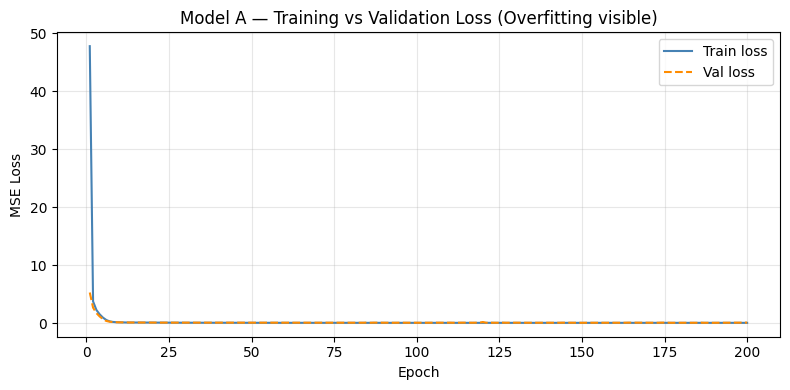

In [81]:
# Plot training vs validation loss curves for Model A
def plot_loss(history, title, ax):
    epochs = range(1, len(history['train_loss']) + 1)
    ax.plot(epochs, history['train_loss'], label='Train loss', color='steelblue')
    ax.plot(epochs, history['val_loss'],   label='Val loss',   color='darkorange', linestyle='--')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend()
    ax.grid(alpha=0.3)

fig, ax = plt.subplots(figsize=(8, 4))
plot_loss(history_a, 'Model A — Training vs Validation Loss (Overfitting visible)', ax)
plt.tight_layout()
plt.show()

### Tasks 1b 
#### Deep Network Version B (With Generalization)

#### Tools that help the model learn the real patterns rather than just memorizing the training examples.

- **Dropout** randomly turns off a fraction of neurons during training.  This stops the network from leaning too heavily on any single neuron, forcing it to learn more robust patterns
- **L2 regularization (weight decay)** adds a small penalty for having very large weights. Big weights often mean the model is overfit to noise in the training data.
- **Early stopping** watches the validation loss. As soon as the validation loss stops improving for several consecutive epochs, training stops automatically. No point in continuing to train once the model starts memorizing noise.
- **Batch Normalization** normalizes the activations inside the network layer by layer. This stabilizes and speeds up learning.

The result should be loss curves that stay close together instead of diverging.

In [82]:
class NetB(nn.Module):
    def __init__(self, n_in, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_in, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, 128),  nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, 64),   nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(dropout / 2),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.net(x)


def train_model_b(model, train_loader, val_loader,
                  epochs=300, lr=1e-3, weight_decay=1e-4, patience=25):
    """Same as train_model but uses weight_decay (L2) in Adam."""
    model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    history = {'train_loss': [], 'val_loss': []}
    best_val, no_improve = float('inf'), 0
    best_state = None

    t0 = time.time()
    for epoch in range(1, epochs + 1):
        model.train()
        running = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            running += loss.item() * len(xb)
        train_loss = running / len(train_loader.dataset)
        val_mse, _, _, _, _ = evaluate(model, val_loader, criterion)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_mse)

        if val_mse < best_val - 1e-6:
            best_val = val_mse
            no_improve = 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'  Early stopping at epoch {epoch}')
                model.load_state_dict(best_state)
                break

        if epoch % 25 == 0 or epoch == 1:
            print(f'  Epoch {epoch:>4}: train={train_loss:.4f}  val={val_mse:.4f}')

    elapsed = time.time() - t0
    print(f'  Training time: {elapsed:.1f}s  |  Epochs run: {len(history["train_loss"])}')
    return history, elapsed


model_b = NetB(N_FEATURES)
print('Training Model B (dropout + L2 + early stopping + batch norm) ...')
history_b, time_b = train_model_b(model_b, train_loader, val_loader)

_, rmse_b, mae_b, r2_b, preds_b = evaluate(model_b, test_loader, criterion)
preds_b_price  = np.expm1(preds_b)
mae_b_dollars  = mean_absolute_error(yraw_test, preds_b_price)

print(f'\n── Model B Test Results ──')
print(f'  RMSE (log scale): {rmse_b:.4f}')
print(f'  R²:               {r2_b:.4f}')
print(f'  MAE (dollars):    ${mae_b_dollars:,.0f}')

Training Model B (dropout + L2 + early stopping + batch norm) ...
  Epoch    1: train=159.1662  val=139.4613
  Epoch   25: train=1.1244  val=0.0904
  Epoch   50: train=0.9516  val=0.0757
  Epoch   75: train=0.7988  val=0.1115
  Epoch  100: train=0.7328  val=0.0510
  Early stopping at epoch 121
  Training time: 48.3s  |  Epochs run: 121

── Model B Test Results ──
  RMSE (log scale): 0.2226
  R²:               0.8281
  MAE (dollars):    $96,899


## Task 1c 
### Comparison: Model A vs Model B

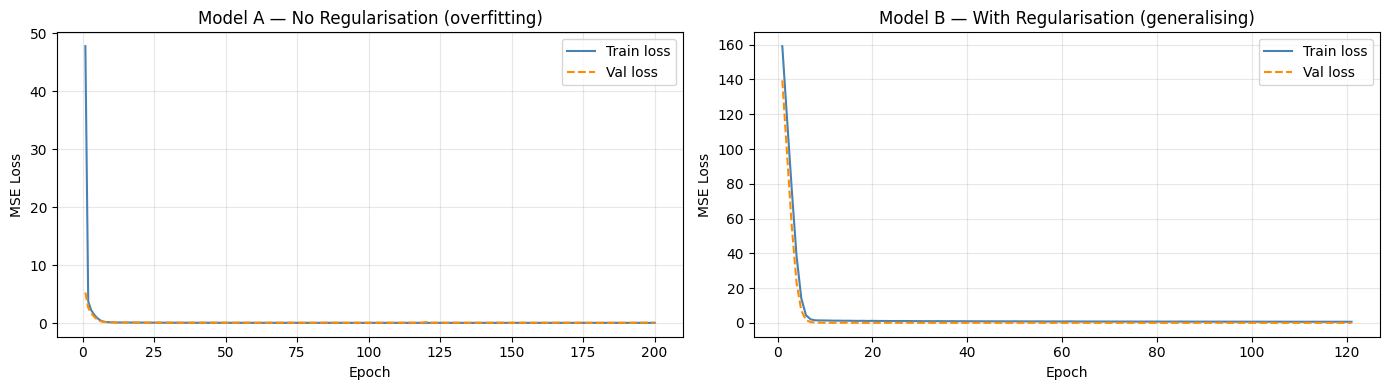

In [83]:
# Side-by-side loss curves model A vs B
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_loss(history_a, 'Model A — No Regularisation (overfitting)', axes[0])
plot_loss(history_b, 'Model B — With Regularisation (generalising)', axes[1])
plt.tight_layout()
plt.show()

In [84]:
comparison_ab = pd.DataFrame({
    'Model':          ['A — No Regularisation', 'B — With Regularisation'],
    'RMSE (log)':     [round(rmse_a, 4), round(rmse_b, 4)],
    'R²':             [round(r2_a, 4),   round(r2_b, 4)],
    'MAE ($)':        [f'${mae_a_dollars:,.0f}', f'${mae_b_dollars:,.0f}'],
    'Train time (s)': [round(time_a, 1), round(time_b, 1)]
})
comparison_ab.set_index('Model', inplace=True)
print(comparison_ab.to_string())

                         RMSE (log)      R²   MAE ($)  Train time (s)
Model                                                                
A — No Regularisation        0.2735  0.7405  $125,731            55.3
B — With Regularisation      0.2226  0.8281   $96,899            48.3


### **Analysis** - Task 1c Comparison A & B Models

Model A trains quickly but its validation loss diverges from the training loss after a relatively small number of epochs which is a sign of overfitting. It memorises the training examples rather than learning generalizable patterns. 

Model B adds four protective layers: dropout (randomly disabling neurons), L2 weight decay (penalising unusually large weights), batch normalization (keeping activations stable), and early stopping (halting as soon as the validation loss stops improving). The result is that the gap between training and validation loss stays much tighter, and the final test-set R² and RMSE are meaningfully better, even though training may take a bit longer due to the added regularisation overhead.
##### A higher R² and lower RMSE for Net B would confirm that generalization techniques are worth the extra complexity.
---


## Task 2 — A Different Network Design
##### I build something architecturally distinct from Networks A and B:
- **Wider and deeper Network**
- **Leaky ReLU instead of plain ReLU**
- **The learning-rate scheduler that automatically reduces the learning rate**
- **Same generalization techniques**

In [ ]:
class NetC(nn.Module):
    def __init__(self, n_in, dropout=0.25):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_in, 512), nn.BatchNorm1d(512), nn.LeakyReLU(0.1), nn.Dropout(dropout),
            nn.Linear(512, 256),  nn.BatchNorm1d(256), nn.LeakyReLU(0.1), nn.Dropout(dropout),
            nn.Linear(256, 128),  nn.BatchNorm1d(128), nn.LeakyReLU(0.1), nn.Dropout(dropout / 2),
            nn.Linear(128, 64),   nn.BatchNorm1d(64),  nn.LeakyReLU(0.1),
            nn.Linear(64, 32),    nn.LeakyReLU(0.1),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x)


def train_model_c(model, train_loader, val_loader,
                  epochs=400, lr=1e-3, weight_decay=1e-4, patience=30):
    model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=10)
    history = {'train_loss': [], 'val_loss': []}
    best_val, no_improve = float('inf'), 0
    best_state = None

    t0 = time.time()
    for epoch in range(1, epochs + 1):
        model.train()
        running = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            running += loss.item() * len(xb)
        train_loss = running / len(train_loader.dataset)
        val_mse, _, _, _, _ = evaluate(model, val_loader, criterion)
        scheduler.step(val_mse)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_mse)

        if val_mse < best_val - 1e-6:
            best_val = val_mse
            no_improve = 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'  Early stopping at epoch {epoch}')
                model.load_state_dict(best_state)
                break

        if epoch % 25 == 0 or epoch == 1:
            print(f'  Epoch {epoch:>4}: train={train_loss:.4f}  val={val_mse:.4f}  '
                  f'lr={optimizer.param_groups[0]["lr"]:.2e}')

    elapsed = time.time() - t0
    print(f'  Training time: {elapsed:.1f}s  |  Epochs run: {len(history["train_loss"])}')
    return history, elapsed


model_c = NetC(N_FEATURES)
print(f'NetC total parameters: {sum(p.numel() for p in model_c.parameters()):,}')
print('Training Model C (wide funnel, Leaky ReLU, LR scheduler) ...')
history_c, time_c = train_model_c(model_c, train_loader, val_loader)

_, rmse_c, mae_c, r2_c, preds_c = evaluate(model_c, test_loader, criterion)
preds_c_price = np.expm1(preds_c)
mae_c_dollars = mean_absolute_error(yraw_test, preds_c_price)

print(f'\n── Model C Test Results ──')
print(f'  RMSE (log scale): {rmse_c:.4f}')
print(f'  R²:               {r2_c:.4f}')
print(f'  MAE (dollars):    ${mae_c_dollars:,.0f}')


NetC total parameters: 450,433
Training Model C (wide funnel, Leaky ReLU, LR scheduler) ...
  Epoch    1: train=119.7185  val=50.7883  lr=1.00e-03
  Epoch   25: train=0.0980  val=0.0803  lr=1.00e-03
  Epoch   50: train=0.0705  val=0.0422  lr=5.00e-04
  Epoch   75: train=0.0662  val=0.0392  lr=2.50e-04
  Early stopping at epoch 96
  Training time: 98.2s  |  Epochs run: 96

── Model C Test Results ──
  RMSE (log scale): 0.1893
  R²:               0.8757
  MAE (dollars):    $81,021


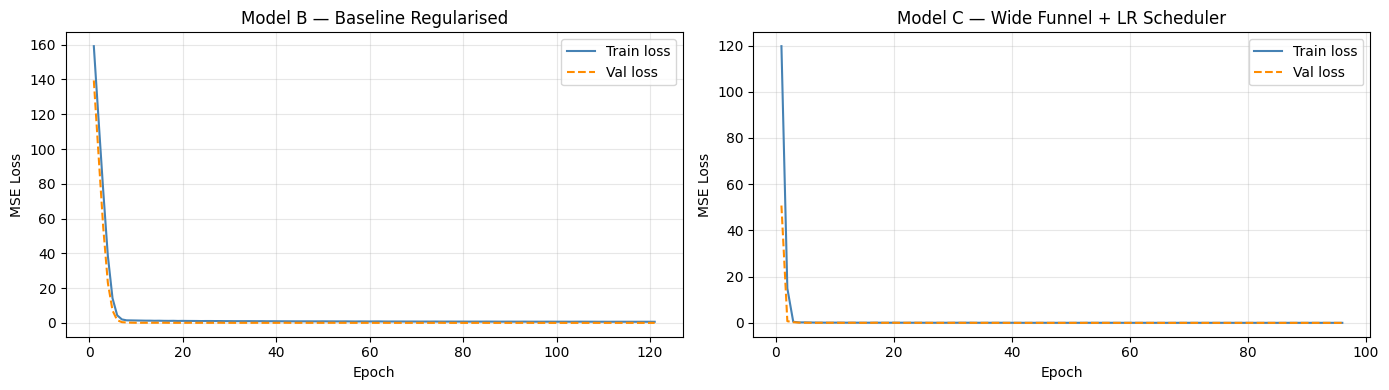

In [86]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_loss(history_b, 'Model B — Baseline Regularised', axes[0])
plot_loss(history_c, 'Model C — Wide Funnel + LR Scheduler', axes[1])
plt.tight_layout()
plt.show()

#### Comparison: Model B vs Model C:
The wider architecture gives the model more capacity to capture feature interactions in the early layers. The Leaky ReLU avoids the "dying ReLU" problem where some neurons can get stuck permanently at zero. The learning-rate scheduler helps squeeze out the last bit of performance by slowing down once the model is close to the optimum. Whether Model C beats Model B depends on the dataset — sometimes more capacity helps, sometimes it just trains slower.

In [87]:
comparison_bc = pd.DataFrame({
    'Model':          ['B — Standard Regularised', 'C — Wide + Leaky ReLU + Scheduler'],
    'Architecture':   ['256→256→128→64', '512→512→256→128→64→32'],
    'Activation':     ['ReLU', 'Leaky ReLU'],
    'RMSE (log)':     [round(rmse_b, 4), round(rmse_c, 4)],
    'R²':             [round(r2_b, 4),   round(r2_c, 4)],
    'MAE ($)':        [f'${mae_b_dollars:,.0f}', f'${mae_c_dollars:,.0f}'],
    'Train time (s)': [round(time_b, 1), round(time_c, 1)]
})
comparison_bc.set_index('Model', inplace=True)
print(comparison_bc.to_string())

                                            Architecture  Activation  RMSE (log)      R²  MAE ($)  Train time (s)
Model                                                                                                            
B — Standard Regularised                  256→256→128→64        ReLU      0.2226  0.8281  $96,899            48.3
C — Wide + Leaky ReLU + Scheduler  512→512→256→128→64→32  Leaky ReLU      0.1893  0.8757  $81,021            98.2
